# Salem Stays: What Drives Airbnb Ratings and Pricing in Oregon's Capital?

Group Members: Emily Strickland, Seira Ramchandani, Sophia Rabbanian, Tiffany Truong

## Section 1: Introduction & Data

Our main research question for this project is: 
**What listing and host characteristics predict an overall review score and pricing in Salem's Airbnb market?**
Additionally, we aim to answer these 5 sub questions to further analyze how the Salem Airbnb market operates.
- Do certain amenities make the Airbnb more popular/more expensive?
- Are there certain “key” words mentioned in the reviews, and does it correlate to higher reviews?
- Does proximity to Salem landmarks affect pricing or ratings? 
- Is Salem's Airbnb market growing, and are there seasonal patterns? 
- Do host characteristics influence ratings?

Our datasets are all collected from [Inside Airbnb](https://insideairbnb.com/get-the-data/), which is public and holds access to quarterly airbnb data for the last year for each region in csv format. Specifically we will be using 3 datasets for our analysis:
- Salem AirBnb Listings (53 cols, 352 rows)
- Salem Airbnb Listings Detailed (85 cols, 280 rows)
- Salem AirBnb Reviews (6 cols, 21,000+ rows)
The Listings Detailed csv holds null values for all property prices, so we will merge with the Listings csv on listing_id to get prices.

In [138]:
# import all the needed libraries for this project
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
import branca.colormap as cm
import ssl
import nltk
import json
import copy
import ast
from scipy import stats
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from collections import Counter

## Load the datasets

This notebook keeps the original section code and explanations as much as possible, while standardizing the file paths to the local project files. Base dataframes are loaded once here and section-specific aliases are created only when needed.

In [139]:
listings_detail = pd.read_csv('salem_detailed_listings.csv')
listings_summary = pd.read_csv('salem_listings.csv')
reviews = pd.read_csv('salem_reviews.csv', parse_dates=['date'])
airbnb_reviews = pd.read_csv('salem_airbnb.csv')
compressed_amenities = pd.read_csv('salem_compressed_amenities.csv')

Once the two files were merged, there were 50 rows with null values in the price column. We decided to impute the median price per room type for the null values since out of the 50, 37 did have ratings, and that could be potentially important information. We followed with a quick sanity check of our data.

In [140]:
listings_detail = pd.read_csv('salem_detailed_listings.csv')
listings_summary = pd.read_csv('salem_listings.csv')
reviews = pd.read_csv('salem_reviews.csv', parse_dates=['date'])

# merge on the price column 
listings_detail = listings_detail.drop(columns='price')  # drop the empty price column first

listings_detail = listings_detail.merge(
    listings_summary[['id', 'price']],
    left_on='id',
    right_on='id',
    how='left'
)

#print(listings_detail.columns.tolist())

# Verify
#print(listings_detail['price'].head(3))
print("Nulls in price:", listings_detail['price'].isnull().sum())

# How many listings in detailed file aren't in the summary file at all?
missing_price_ids = listings_detail[listings_detail['price'].isnull()]['id']
in_summary = missing_price_ids.isin(listings_summary['id'])
print("Missing IDs not in summary file:", (~in_summary).sum())
print("Missing IDs that ARE in summary but price is null:", in_summary.sum())

# Check if those listings have any other useful info
print("\nRoom types of listings with missing price:")
print(listings_detail[listings_detail['price'].isnull()]['room_type'].value_counts())

print("\nDo they have ratings?")
print(listings_detail[listings_detail['price'].isnull()]['review_scores_rating'].notna().sum())

# Impute missing price with median price per room type
listings_detail['price'] = listings_detail.groupby('room_type')['price'].transform(
    lambda x: x.fillna(x.median())
)


Nulls in price: 50
Missing IDs not in summary file: 34
Missing IDs that ARE in summary but price is null: 16

Room types of listings with missing price:
room_type
Entire home/apt    38
Private room       12
Name: count, dtype: int64

Do they have ratings?
37


In [141]:
# Quick sanity check
print(f"Listings shape: {listings_detail.shape}")
#280 rows of property listings
print(f"Reviews shape: {reviews.shape}")
#21319 rows of reviews on properties
print(f"\nPrice range: ${listings_detail['price'].min():.0f} — ${listings_detail['price'].max():.0f}")
# price range goes from 30 dollars to 1000 dollars
print(f"Listings with ratings: {listings_detail['review_scores_rating'].notna().sum()}")
# 246 listings that have reviews
print(f"Reviews date range: {reviews['date'].min().date()} — {reviews['date'].max().date()}")
# reviews date range from 2011 August to 2025 September

Listings shape: (280, 85)
Reviews shape: (21319, 6)

Price range: $30 — $1000
Listings with ratings: 246
Reviews date range: 2011-08-29 — 2025-09-24


# Trends Over Time and Neighborhood Activity

# Exploratory Data Analysis

## EDA 1: Salem Airbnb Over Time

Exploring and visualizing the change/trends over time in Airbnb
review/activity can allow us to understand how Salem’s Airbnb market as
it stands currently. The visual below, shows a significant increase in
reviews/activities between 2011-2025.

In [142]:
df = airbnb_reviews.copy()

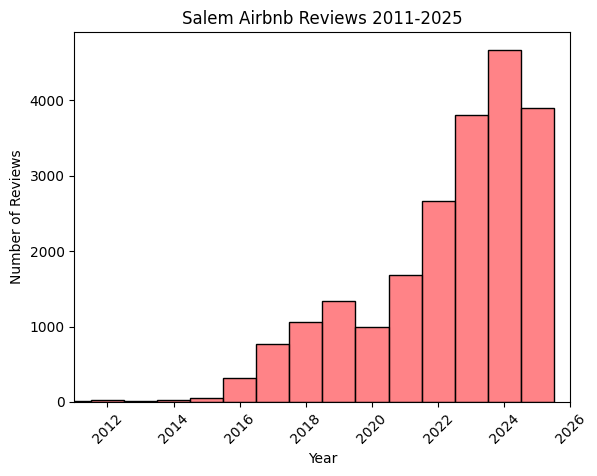

In [143]:
# Converting Date From a String to a Date Data Type
df['date'] = pd.to_datetime(df['date'])

# Getting the year from the Date
df['review_year'] = df['date'].dt.year

# Creating a Histogram to see the growth of reviews/activities for each year
g = sns.histplot(df, x= "review_year", discrete = True, color = "#FF5A5F")
plt.xticks(rotation = 45)
plt.xlim(2011,2026)
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Salem Airbnb Reviews 2011-2025')
plt.show()

The increase in reviews and activity over time indicates a growing
market in Salem’s Airbnb market. A growing Airbnb market will likely
mean increases in competition as more Airbnb hosts enter the market to
support this growing market. For individual Airbnb hosts, this indicates
a growing need for strategic presentation/marketing and prepartion of
Airbnb properties to increase their competitive edge.

Our subsequent exploration and modeling will allow us to understand and
explore what features of Airbnb listings can increase the competitive
edge of Airbnb properties.

## EDA 2: Seasonal Patterns - Months

In addition to exploring the growth of Salem’s Airbnb market overtime,
our team was also interested in exploring how seasonality affects
activity in Salem’s Airbnb market.

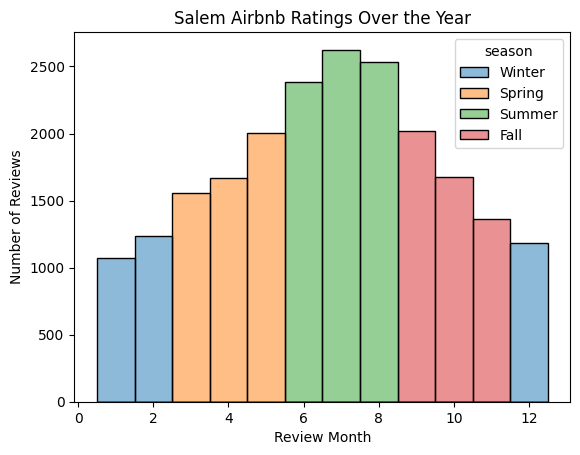

In [144]:
# Getting the month from the Date column
df["review_month"]  = df['date'].dt.month

df = df.sort_values(by = 'review_month')

## REVIEWS BY MONTH
#g = sns.histplot(df, x = "review_month", discrete = True)
#plt.show()

# COLORING REVIEWS BY MONTH BY SEASON
conditions_list = [(df['review_month'] == 12) | (df['review_month'] <= 2), 
                   (df['review_month'] >= 3) & (df['review_month'] <= 5),
                   (df['review_month'] >= 6) & (df['review_month'] <= 8),
                   (df['review_month'] >= 9) & (df['review_month'] <= 11)]

season_list = ['Winter', 'Spring', 'Summer', 'Fall']
df['season'] = np.select(conditions_list, season_list, default = "unknown")
g = sns.histplot(df, x = "review_month", discrete = True, hue = 'season')
plt.xlabel("Review Month")
plt.ylabel("Number of Reviews")
plt.title('Salem Airbnb Ratings Over the Year')
plt.show()

## EDA 3: Price Distribution In Data

Price and Ratings are our main values of interest, so we want to take a look into how they are distributed. The boxplots show the price distribution by room type, and the histogram plots the price distribution with the mean and median. From both, you can see that there are two extreme outliers that have a price of over 700 dollars/night. The outliers are slightly skewing the mean, which is shown in the histogram. We remove the outliers in the second boxplot to show the distribution a bit clearer. Entire homes generally range from 100 - 150 dollars/night, while private rooms are around 50 dollars/night.

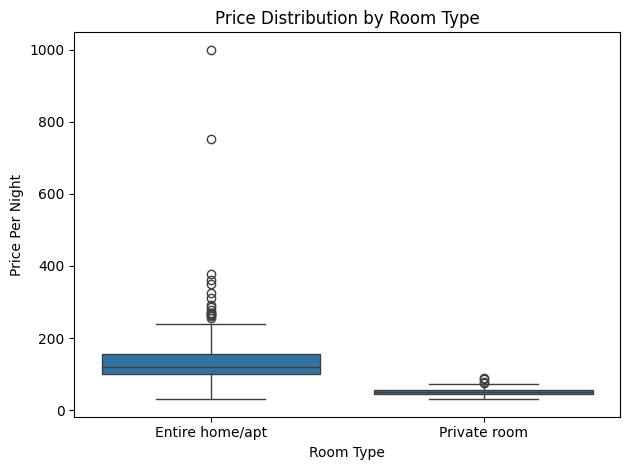

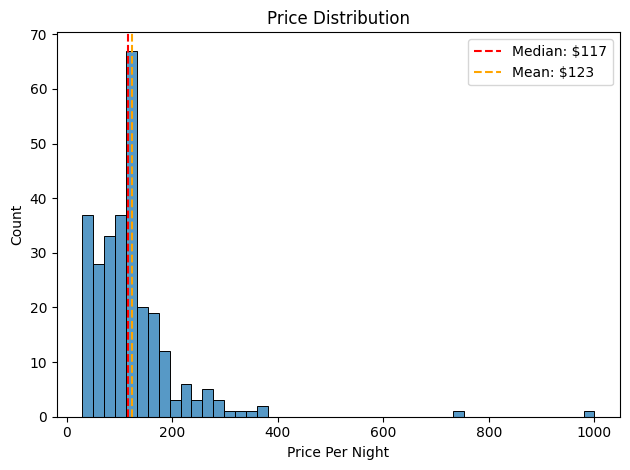

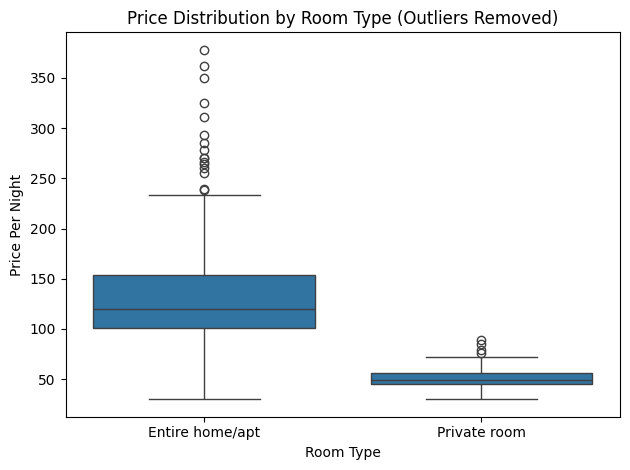

In [145]:
sns.boxplot(listings_detail,x="room_type",y="price")
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price Per Night")
plt.tight_layout()
plt.show()
# there are 2 huge outliers in the data

# histogram plotting the same data
sns.histplot(listings_detail,x="price")
median_price = listings_detail['price'].median()
mean_price = listings_detail['price'].mean()

plt.axvline(median_price, color='red', linestyle='--', label=f"Median: ${median_price:.0f}")
plt.axvline(mean_price, color='orange', linestyle='--', label=f"Mean: ${mean_price:.0f}")

plt.legend()
plt.title("Price Distribution")
plt.xlabel("Price Per Night")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# what about the boxplot distribution if we removed the outliers
#print(listings_detail[listings_detail["price"] > 700])

listings_detail_price_outliers = listings_detail.drop(listings_detail[listings_detail["price"] > 700].index)
sns.boxplot(listings_detail_price_outliers,x="room_type",y="price")
plt.title("Price Distribution by Room Type (Outliers Removed)")
plt.xlabel("Room Type")
plt.ylabel("Price Per Night")
plt.tight_layout()
plt.show()


### Rating Distribution

We use histograms to visualize the rating distribution of listings. 

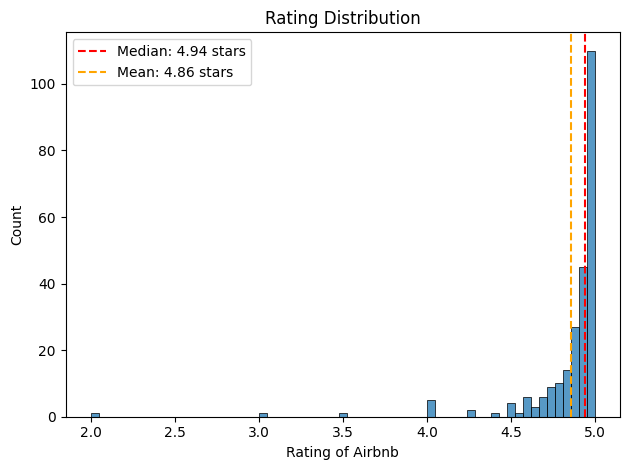

In [146]:
sns.histplot(listings_detail,x="review_scores_rating")
median_rating = listings_detail['review_scores_rating'].median()
mean_rating = listings_detail['review_scores_rating'].mean()

plt.axvline(median_rating, color='red', linestyle='--', label=f"Median: {median_rating:.2f} stars")
plt.axvline(mean_rating, color='orange', linestyle='--', label=f"Mean: {mean_rating:.2f} stars")

plt.legend()
plt.title("Rating Distribution")
plt.xlabel("Rating of Airbnb")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Ratings are heavily left skewed, which shows that people generally leave positive reviews over negative ones, and we can assume that houses that have constant low reviews get delisted. The second histogram is a narrowed view, showing only ratings over 4.0.

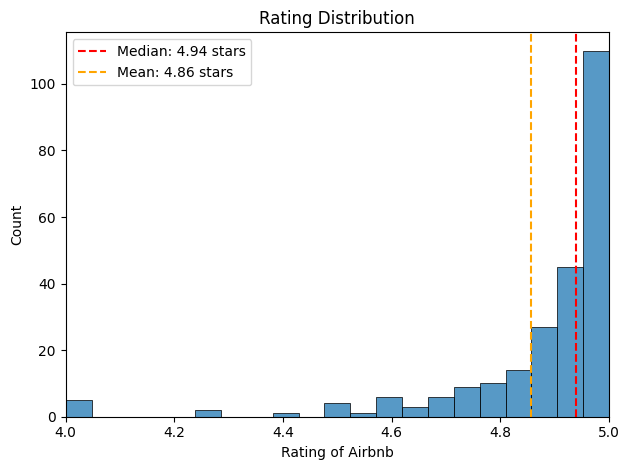

In [147]:
sns.histplot(listings_detail,x="review_scores_rating")
median_rating = listings_detail['review_scores_rating'].median()
mean_rating = listings_detail['review_scores_rating'].mean()

plt.axvline(median_rating, color='red', linestyle='--', label=f"Median: {median_rating:.2f} stars")
plt.axvline(mean_rating, color='orange', linestyle='--', label=f"Mean: {mean_rating:.2f} stars")

plt.xlim(4.0, 5.0)
plt.legend()
plt.title("Rating Distribution")
plt.xlabel("Rating of Airbnb")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
# this is a more narrowed view to see closely what the higher end review distribution looks like

### Airbnb locations in Salem

Next, we wanted to look at geographic features of the airbnbs in Salem. The interactive maps allow you to click on properties and check their neighborhood, price/night, rating, and room type. Landmarks that are frequently mentioned in the listings are Mill Creek, Hospital, Willamette, Capitol, Riverfront, Downtown, and Bush Park. We look at properties on a color scale based on price to see if there are any particular locations that are expensive. The two properties that are over 700 dollars were removed for this map.

In [148]:
# Create color scale based on price
colormap = cm.LinearColormap(
    colors=['green', 'yellow', 'red'],
    vmin=listings_detail_price_outliers['price'].min(),
    vmax=listings_detail_price_outliers['price'].max(),
    caption='Price per Night ($)'
)

# Center map on Salem, OR
salem_map = folium.Map(location=[44.9429, -123.0351], zoom_start=12)

# Plot each listing
for _, row in listings_detail_price_outliers.iterrows():
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']):
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=6,
            color=colormap(row['price']),
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(
                f"""
                <b>{row['name']}</b><br>
                Neighbourhood: {row['neighbourhood_cleansed']}<br>
                Price: ${row['price']:.0f}/night<br>
                Rating: {row['review_scores_rating'] if pd.notnull(row['review_scores_rating']) else 'No rating'}<br>
                Room type: {row['room_type']}
                """,
                max_width=200
            )
        ).add_to(salem_map)

# Add colormap legend to map
colormap.add_to(salem_map)

salem_map

We see that homes with "historical" features have higher prices, as well as properties on the outskirts of Salem that highlight the Willamette Valley and wineries. For neighborhoods, West Salem shows on average a higher pricing, due to the hills having nicer houses and views.
Next, we looked at properties on a color scale based on properties. Overall, ratings appear to be solid and not related to landmarks. The lowest rating that exists in our dataset is the house that costs 1000 dollars/night.

In [149]:
# Color scale based on rating
colormap_rating = cm.LinearColormap(
    colors=['red', 'yellow', 'green'],
    vmin=listings_detail['review_scores_rating'].min(),
    vmax=listings_detail['review_scores_rating'].max(),
    caption='Overall Rating'
)

# Center map on Salem, OR
salem_map_rating = folium.Map(location=[44.9429, -123.0351], zoom_start=12)

for _, row in listings_detail.iterrows():
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']) and pd.notnull(row['review_scores_rating']):
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=6,
            color=colormap_rating(row['review_scores_rating']),
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(
                f"""
                <b>{row['name']}</b><br>
                Neighbourhood: {row['neighbourhood_cleansed']}<br>
                Price: ${row['price']:.0f}/night<br>
                Rating: {row['review_scores_rating']:.2f}<br>
                Room type: {row['room_type']}
                """,
                max_width=200
            )
        ).add_to(salem_map_rating)

colormap_rating.add_to(salem_map_rating)

salem_map_rating

# Loading libraries and getting data | Superhost

In [150]:
# Use the detailed listings file plus reviews to reproduce the merged modeling dataframe
listings_sophia = pd.read_csv('salem_list_SOPHIA.csv').copy()
reviews_sophia = pd.read_csv('salem_reviews.csv').copy()

airbnb = pd.merge(
    listings_sophia,
    reviews_sophia,
    left_on="id",
    right_on="listing_id",
    how="inner"
)

# cleaning up dataframe
# renaming cols
airbnb = airbnb.rename(columns={
    "id_x": "listing_id2",
    "id_y": "review_id"
})
# dropping duplicate columns
airbnb.drop(["listing_id2", "listing_url", "picture_url", "host_url"], axis=1, inplace=True, errors="ignore")

# Linear Regression

## Superhost

### We hypothesize that superhosts will have a higher rating on average.

In [151]:
airbnb["host_is_superhost"] = airbnb["host_is_superhost"].map({"t": 1, "f": 0})

airbnb_model = airbnb[["host_is_superhost", "review_scores_rating"]].dropna()

X = airbnb_model[["host_is_superhost"]]
y = airbnb_model["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R^2:", r2)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

MSE: 0.005894522872031102
R^2: 0.05249130725231521
Intercept: 4.865714899098324
Coefficient: 0.056941117217107734


Findings: We expect non superhosts to have an average rating of 4.87, with an score increase of 0.05 if they are a superhost. this makes logical sense, as superhosts are labeled as those who consistently have outstanding guest experiences.

## Host Response Time

### We hypothesize that hosts that respond quicker get higher ratings. The data is mapped such that the more frequent responses have the higher integer value.

In [152]:
response_time_mapping = {
    "within an hour": 4,
    "within a few hours": 3,
    "within a day": 2,
    "a few days or more": 1
}

airbnb["host_response_time_num"] = airbnb["host_response_time"].map(response_time_mapping)

airbnb["host_response_time_num"] = airbnb["host_response_time_num"].fillna(airbnb["host_response_time_num"].median())

X = airbnb[["host_response_time_num"]]
y = airbnb["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

mse = mean_squared_error(y_test, preds)
print(mse)

model = LinearRegression()
model.fit(X_train, y_train)

corrCoeff = airbnb[["host_response_time_num", "review_scores_rating"]].corr()

print("Coefficient: ", model.coef_)
print("intercept: ", model.intercept_)
print("Correlation Coefficient: ", corrCoeff)

0.0068834369059015115
Coefficient:  [-0.00375383]
intercept:  4.929568051805152
Correlation Coefficient:                          host_response_time_num  review_scores_rating
host_response_time_num                1.000000             -0.015099
review_scores_rating                 -0.015099              1.000000


Findings: A host that responds once every few days or more will have an average rating of 4.93, with a score decrease of .003 as they respond within the next frequency category. This does not make logical sense, but since the coefficient is so small, it is practically meaningless. Overall, response time/frequency has very little impact on the review rating.

# Multiple Linear Regression 

## All Review Categories: Accuracy, Cleanliness, Check-In Process, Communication, Value, Location

### We are curious to see which review category has the most impact and is the most closely correlated to the overall rating score.

In [153]:
X = airbnb[[
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]]

y = airbnb['review_scores_rating']

X = X.dropna()
y = y.loc[X.index]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

airbnb.loc[X.index, 'predicted_rating'] = model.predict(X)

Intercept: -1.0840980496295067
Coefficients: {'review_scores_accuracy': np.float64(0.46324011589806213), 'review_scores_cleanliness': np.float64(0.26487076129610954), 'review_scores_checkin': np.float64(0.03202312256097924), 'review_scores_communication': np.float64(0.29849628784374377), 'review_scores_location': np.float64(0.051107813467749695), 'review_scores_value': np.float64(0.10739655214667555)}


Findings: If the review rates every category as a 0, we expect the overall score to be -1 (this is not possible). The category with the largest impact is accuracy, followed by cleanliness and communication. Those with the lowest impact are value and location.

## Neighbourhoods/Wards

### Reviews Based on Wards

Our team also looked at the data from a geographic lens.

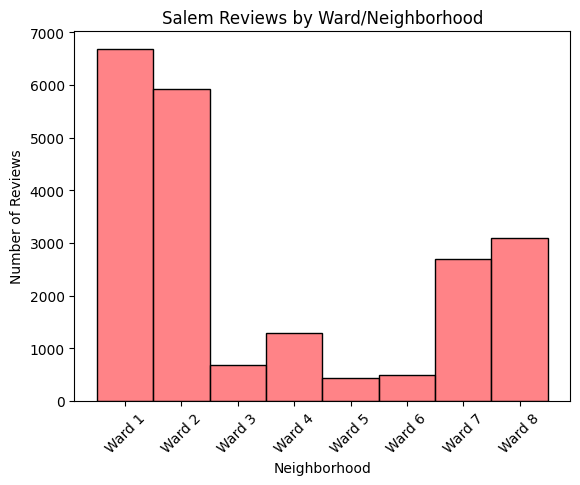

In [154]:
# Setting the Neighbourhood Order
neighborhood_order = ['Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']

# Turning the Neighbourhood column into a categorical neighbourhood
df['neighbourhood'] = pd.Categorical(df['neighbourhood'], categories = neighborhood_order, ordered = True)

# Barplot
g = sns.histplot(df, x = 'neighbourhood', color = "#FF5A5F")
plt.xticks(rotation = 45)
plt.title("Salem Reviews by Ward/Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Reviews")
plt.show()

Overwhelmingly, Ward 1 and Ward 2 are the neighbourhoods with the most
reviews/actvity. Ward 1 covers downtown Salem (and parts of West Salem)
and Ward 2 covers South Salem. This pattern makes sense as these
neighbourhoods are where convention centers, main events and landmarks
are often located. Furthermore, Ward 1 and 2 (encapsulating
downtown/South Salem) can also affect room types as these areas may have
smaller properties.

# CLASSIFICATION OF WARD

To continue our exploration of wards/neighbourhoods within the Salem
Airbnb market, we were interested in the ability to classify ward using
various features in the dataset.

## Preparing to Model

We chose a KNN classification model using price, minimum nights and
availability throughout the year as our features. Using cross
validation, we came to the conclusion that K = 2 or K = 3 is the best K.
Additionally, we split our dataset into training,testing sets that were
stratified by Ward to account for class/ward/neighbourhood imbalance in
our dataset.

# Decision Tree Classification

## Classifying Room Type

### We are curious what are some patterns within each of the different room types (either entire apartment/home or private room). We believe there will be trends with how many guests the airbnb accommodates as well as the ward (or neighborhood).

Accuracy: 0.8836772983114447

Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.91      0.93      0.92      3056
     Hotel room       0.00      0.00      0.00         2
   Private room       0.81      0.77      0.79      1206

       accuracy                           0.88      4264
      macro avg       0.57      0.57      0.57      4264
   weighted avg       0.88      0.88      0.88      4264



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

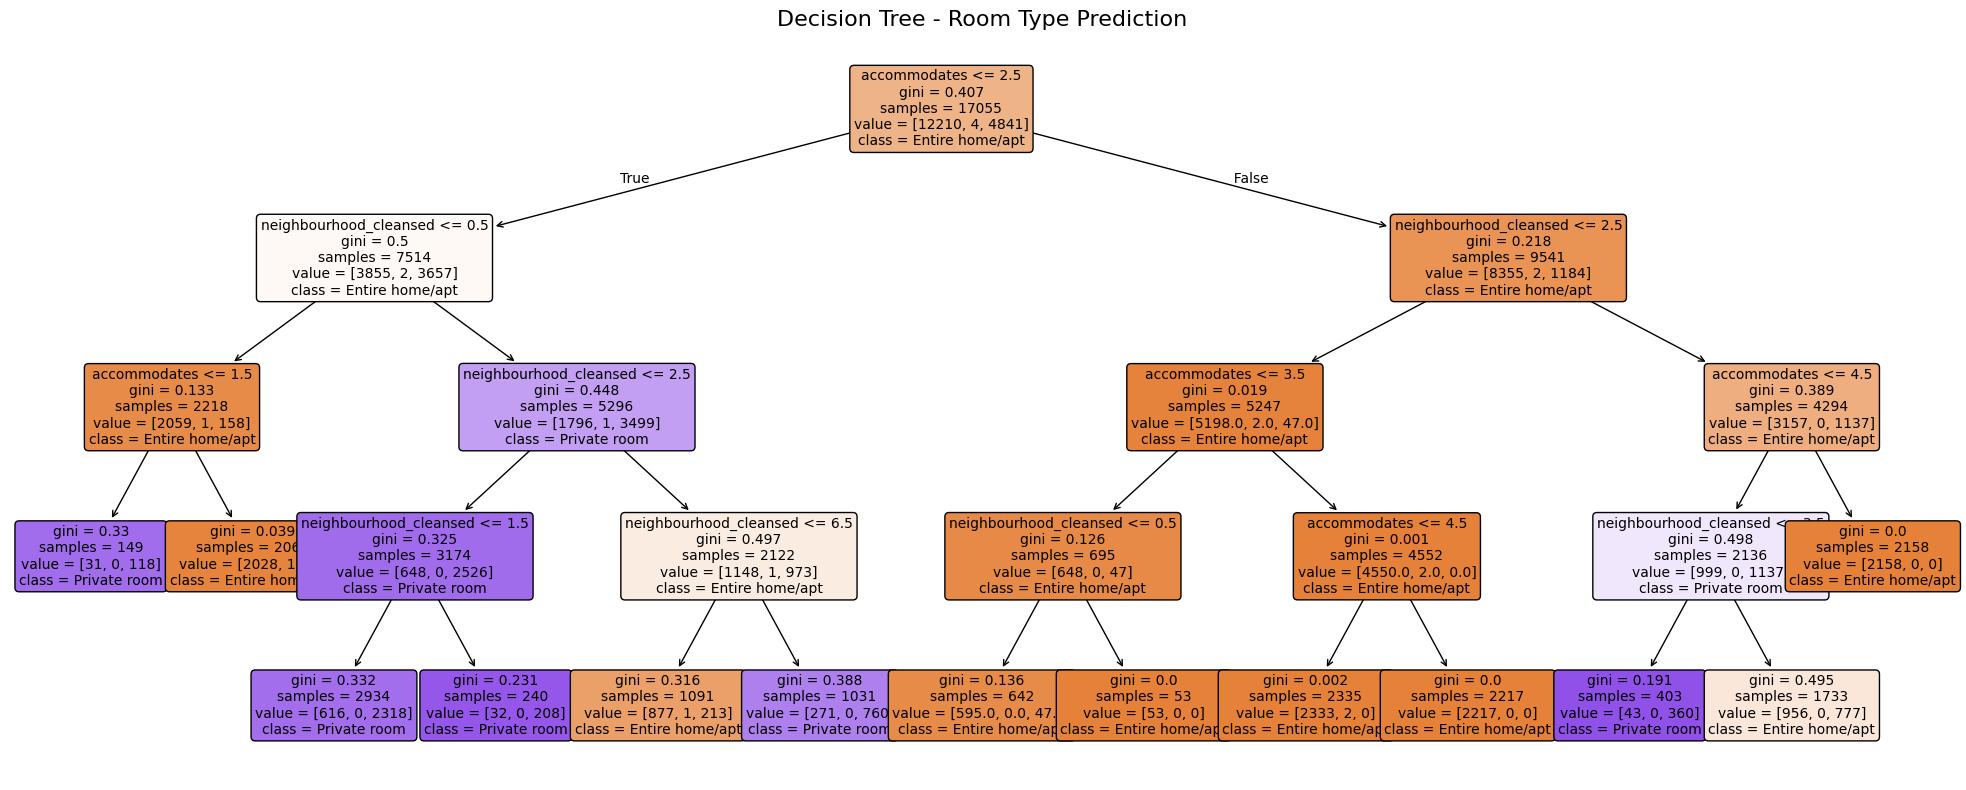

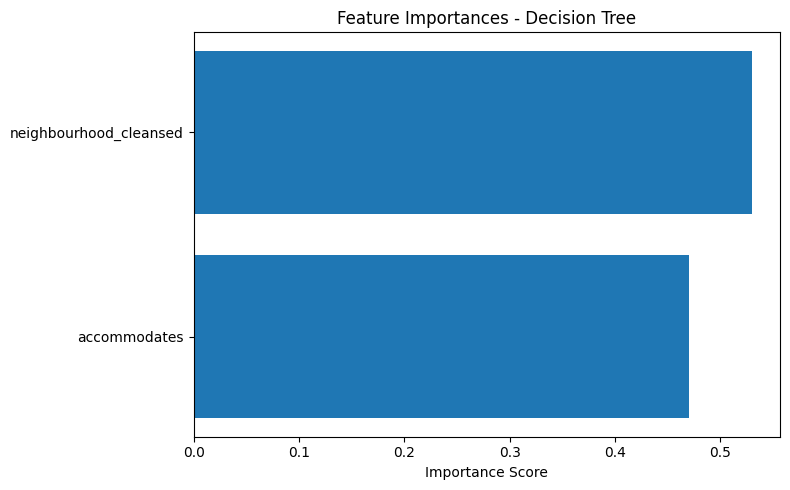

In [155]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import to_hex
import matplotlib.cm as cm

features = ["accommodates", "neighbourhood_cleansed"]
target = "room_type"

airbnb3 = airbnb[features + [target]].dropna()

# Encode categorical feature
le_neighbourhood = LabelEncoder()
airbnb3["neighbourhood_encoded"] = le_neighbourhood.fit_transform(airbnb3["neighbourhood_cleansed"])

# Encode target
le_target = LabelEncoder()
airbnb3["room_type_encoded"] = le_target.fit_transform(airbnb3[target])

X = airbnb3[["accommodates", "neighbourhood_encoded"]]
y = airbnb3["room_type_encoded"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier(
    max_depth=4,         # Limits tree depth to avoid overfitting
    min_samples_split=10, # Minimum samples required to split a node
    min_samples_leaf=5,   # Minimum samples required at a leaf node
    criterion="gini",     # Split quality metric ("gini" or "entropy")
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(
    model,
    feature_names=["accommodates", "neighbourhood_cleansed"],
    class_names=le_target.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree - Room Type Prediction", fontsize=16)
plt.set_cmap("plasma") 
plt.tight_layout()
plt.show()

# Feature importance plot
plt.figure(figsize=(8, 5))
plt.barh(["accommodates", "neighbourhood_cleansed"], model.feature_importances_)
plt.title("Feature Importances - Decision Tree")
plt.xlabel("Importance Score")
#plt.
plt.tight_layout()
plt.show()

Findings: The neighborhood is generally more impactful in classifying the room type. Overall, the takeaway is that usually private rooms are listed as accommodating only one person (not even a couple). Places with lower ward numbers are more often private rooms (this makes sense considering that Ward 1 is downtown and likely has less complete homes available).

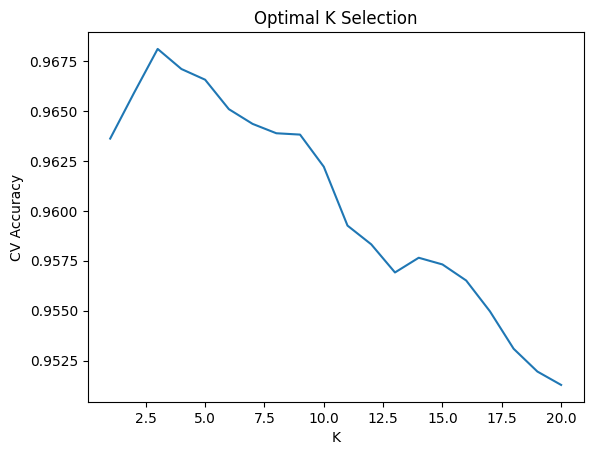

In [156]:
# Loading Dataframe 
dfs = airbnb_reviews.copy()

# DROP UNNECESSARY COLUMNS AND CREATE MODELING DATA FRAME
model_dfs = dfs.drop(['neighbourhood_group', 'longitude', 'latitude'], axis=1)

# NA values in model features
model_dfs['price'] = model_dfs['price'].fillna(model_dfs['price'].median())
model_dfs['availability_365'] = model_dfs['availability_365'].fillna(model_dfs['availability_365'].median())
model_dfs['minimum_nights'] = model_dfs['minimum_nights'].fillna(model_dfs['minimum_nights'].median())

# remove rows where target is missing
model_dfs = model_dfs.dropna(subset=['neighbourhood'])

# X and Y
X = model_dfs[['price', 'availability_365', 'minimum_nights']]
y = model_dfs['neighbourhood']

# 2. Split Data into testing and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

# 3. Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform only — never refit on test data


# 4. Cross-Validation to identify a good K
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_range = range(1, 21)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5).mean() 
             for k in k_range]

plt.plot(k_range, cv_scores)
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.title('Optimal K Selection')
plt.show()

# 5.Initialize the model with K = 2
knn = KNeighborsClassifier(n_neighbors=2 )

# 6. Fit the model
knn.fit(X_train, y_train)

# 7. Predict
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
knnPredict = knn.predict(X_test)

## Modeling and Assessing Accuracy, Precision, Recall and F1

After modeling we assessed the accuracy of our model using our testing
set. For this we calculated accuracy, precision, recall and F1

Due to the multiclass nature of our model, we indicated the ‘average’
parameter as “weighted” for Precision, Recall and F1. This is to account
for any class/neighbourhood and ward imbalances in our dataset when we
are averaging precision, recall and F1 across the different
classes/wards.

### The Scores

In [157]:
## Choosing weighted to account for class imbalances particularly with ward 5
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy:  {accuracy_score(y_test, knnPredict):.4f}")
print(f"Precision: {precision_score(y_test, knnPredict, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, knnPredict, average='weighted'):.4f}")
print(f"F1:        {f1_score(y_test, knnPredict, average='weighted'):.4f}")

Accuracy:  0.9689
Precision: 0.9715
Recall:    0.9689
F1:        0.9685


#### What do our Scores mean?

-   **Accuracy:** Accuracy indicates the proportion of correct
    predictions made by the model out of all the predictions. Our
    acccuracy score indicates that of all the predictions, our model
    predicted 96% of them correctly.
-   **Precision:** Precision measures how many of the predictions for
    each ward are actually correct. Our precision score indicates that
    on average, 97% of predictions for each class/ward are correctly
    predicted.
-   **Recall:** Recall measures the our model’s ability to identify all
    true instances of a particular class. Our recall of 96% indicates
    that on average, 96% of the actual/true wards were correctly
    classified by our model.
-   **F1:** Taking the harmonic mean of precision and recall, our F1
    score of 96% indicates that our model perofrms well in both
    precision and recall.

### The Confusion Matrix

Looking at our confusion matrix, we see that our high accuracy,
precision, recall and F1 score are reflected in the predicted label vs
actual label within the matrix. Overall, most classes/wards were
correctly predicted using our model though there are a few instances of
misclassification.

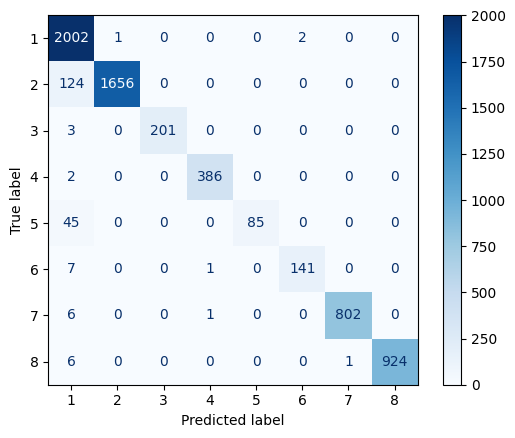

In [158]:
# Confusion Matrix
cm = confusion_matrix(y_test, knnPredict)
disp = ConfusionMatrixDisplay(cm, display_labels = ['1', '2', '3', '4', '5', '6', '7', '8'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### Some things to note:

-   **WARD 1 & 2 have a high misclassification rate:** Of the data
    points predicted as Ward 1 (2215), 2002 were correctly classified.
    However, a signficant amount of data points were also misclassified
    as Ward 1 when they were actually Ward 2; that is a misclassifcation
    rate of 5.5% (124/2215).

-   **WARD 1 & 5 also have high misclassification:** In addition to
    misclassification between Ward 1 and Ward 2, Ward 5 is often
    misclassified as Ward 1. In fact, Ward 5 has the highest
    misclassification rate at 34.5% (45/130 total data points
    misclassified as Ward 1).

#### Some considerations for these misclassifications:

Upon looking at the geographical distribution of wards/neighbourhoods in
Salem, we found that Ward 1, 2 and 5 are all adjacent to one another.
That is, they are next to eachother. This suggests that there may be
some similarities and overlap in terms of pricing and property
characteristics as these wards are close to one another.

Furthermore, the variation in ability to classify Ward 5, can likely be
a result of it being a less represented ward/neighbourhood within our
data set. There are simply not enough data points within our training
and testing sets to effectively classify this ward consistently.

## Amenities Feature Engineering

## Import

#### 1. Read in the original csv

In [159]:
dfe = pd.read_csv('salem_detailed_listings.csv')

#### 2. Parse the amenities column into a real Python list

In [160]:
def parse_amenities(x):
    if pd.isna(x):
        return []
    try:
        return json.loads(x)
    except:
        return []

dfe["amenities_list"] = dfe["amenities"].apply(parse_amenities)

#### 3. Create the compressed amenity map

In [161]:
amenity_map = {
    "has_tv": ["tv", "hdtv", "television"],
    "has_streaming": [
        "netflix", "hulu", "roku", "disney+", "amazon prime video",
        "apple tv", "fire tv", "hbo max", "chromecast", "premium cable",
        "standard cable", "dvd player"
    ],
    "has_wifi": ["wifi", "internet"],
    "has_fast_wifi": ["fast wifi", "mbps"],

    "has_kitchen": ["kitchen"],
    "has_kitchenette": ["kitchenette"],
    "has_coffee_maker": [
        "coffee maker", "keurig", "nespresso", "espresso machine",
        "french press", "pour over coffee", "drip coffee maker"
    ],
    "has_microwave": ["microwave"],
    "has_dishwasher": ["dishwasher"],
    "has_refrigerator": ["refrigerator", "fridge", "mini fridge", "freezer"],
    "has_oven": ["oven"],
    "has_stove": ["stove", "gas stove", "electric stove", "induction stove"],

    "has_air_conditioning": [
        "air conditioning", "ac", "window ac unit",
        "portable air conditioning", "central air conditioning"
    ],
    "has_heating": ["heating", "central heating", "radiant heating", "portable heater"],
    "has_ceiling_fan": ["ceiling fan", "portable fans"],

    "has_washer": ["washer"],
    "has_dryer": ["dryer"],
    "has_parking": ["parking", "garage", "carport", "driveway", "free street parking", "paid parking"],
    "has_ev_charger": ["ev charger"],

    "has_pool": ["pool"],
    "has_hot_tub": ["hot tub", "jacuzzi"],
    "has_gym": [
        "gym", "exercise equipment", "workout bench",
        "stationary bike", "elliptical", "free weights", "yoga mat"
    ],
    "has_fireplace": ["fireplace"],
    "has_bbq_grill": ["bbq grill", "barbecue", "grill"],
    "has_fire_pit": ["fire pit"],

    "has_outdoor_dining": ["outdoor dining area", "outdoor furniture"],
    "has_backyard": ["backyard"],
    "has_patio_balcony": ["patio", "balcony"],
    "has_private_entrance": ["private entrance"],

    "has_workspace": ["dedicated workspace", "workspace", "desk"],
    "has_self_check_in": ["self check-in"],
    "has_lockbox_or_smart_lock": ["lockbox", "smart lock", "keypad"],

    "has_hair_dryer": ["hair dryer"],
    "has_iron": ["iron"],
    "has_hot_water": ["hot water", "hot water kettle"],
    "has_bathtub": ["bathtub"],
    "has_shampoo": ["shampoo"],
    "has_conditioner": ["conditioner"],
    "has_body_soap": ["body soap", "body wash", "shower gel"],
    "has_bed_linens": ["bed linens"],
    "has_extra_pillows_blankets": ["extra pillows and blankets"],
    "has_hangers": ["hangers"],
    "has_clothing_storage": ["clothing storage", "closet", "dresser", "wardrobe", "walk-in closet"],

    "has_view": [
        "view", "bay view", "canal view", "city skyline view", "courtyard view",
        "garden view", "mountain view", "park view", "pool view", "river view",
        "valley view", "vineyard view", "waterfront"
    ],

    "has_family_features": [
        "crib", "high chair", "baby bath", "baby monitor", "changing table",
        "children’s books and toys", "children's books and toys", "children's playroom",
        "children’s dinnerware", "children's dinnerware", "pack ’n play travel crib",
        "pack 'n play travel crib", "outlet covers", "table corner guards",
        "baby safety gates", "booster seat"
    ],

    "has_pet_friendly": ["pets allowed"],

    "has_safety_features": [
        "smoke alarm", "carbon monoxide alarm", "fire extinguisher",
        "first aid kit", "fireplace guards"
    ],
    "has_smoke_alarm": ["smoke alarm"],
    "has_carbon_monoxide_alarm": ["carbon monoxide alarm"],
    "has_first_aid_kit": ["first aid kit"],
    "has_fire_extinguisher": ["fire extinguisher"],

    "has_security_cameras": ["security cameras", "exterior security cameras", "noise decibel monitors"],

    "has_game_features": [
        "arcade games", "board games", "game console", "ping pong table",
        "pool table", "record player", "piano", "movie theater", "life size games"
    ],

    "has_luxury_features": [
        "resort access", "private hot tub", "private outdoor pool",
        "sun loungers", "building staff", "housekeeping", "private outdoor kitchen"
    ],

    "has_cooking_basics": ["cooking basics"],
    "has_dishes_silverware": ["dishes and silverware"],
    "has_dining_area": ["dining table"],
    "has_small_appliances": ["toaster", "blender", "rice maker", "bread maker"],
    "has_baking_tools": ["baking sheet"],

    "has_cleaning_products": ["cleaning products"],
    "has_essentials": ["essentials"],

    "has_coffee": ["coffee"],
    "has_wine_glasses": ["wine glasses"],

    "has_room_darkening": ["room-darkening shades", "room darkening shades"],
    "has_books": ["books and reading material"],
    "has_private_living_space": ["private living room"],

    "has_long_term_stays": ["long term stays allowed"],
    "has_luggage_dropoff": ["luggage dropoff allowed"],
    "has_host_interaction": ["host greets you"],

    "has_lock_on_bedroom": ["lock on bedroom door"],
    "has_safe": ["safe"],

    "has_ethernet": ["ethernet connection"],
    "has_sound_system": ["sound system", "bluetooth sound system"],

    "has_laundromat_nearby": ["laundromat nearby"],

    "is_single_level": ["single level home"],

    "has_hammock": ["hammock"],
    "has_breakfast": ["breakfast"],
    "has_bidet": ["bidet"],
    "has_babysitting": ["babysitter recommendations"],
    "has_theme_room": ["theme room"]
}

#### 4. Function to map amentites into compressed binary features

In [162]:
def map_amenities(amenities):
    amenities_lower = [str(a).lower() for a in amenities]
    result = {}

    for feature, keywords in amenity_map.items():
        result[feature] = int(
            any(
                any(keyword in amenity for keyword in keywords)
                for amenity in amenities_lower
            )
        )

    return pd.Series(result)

# Create compressed features
amenity_features = dfe["amenities_list"].apply(map_amenities)

# Join to original dataframe
dfe = pd.concat([dfe, amenity_features], axis=1)

#### 5. Add amenity count

In [163]:
dfe["amenity_count"] = dfe["amenities_list"].apply(len)

#### 6. Find unmatched amenities

In [164]:
def unmatched_amenities(amenities):
    amenities_lower = [str(a).lower() for a in amenities]
    unmatched = []

    for amenity in amenities_lower:
        matched = False
        for keywords in amenity_map.values():
            if any(keyword in amenity for keyword in keywords):
                matched = True
                break
        if not matched:
            unmatched.append(amenity)

    return unmatched

dfe["unmatched_amenities"] = dfe["amenities_list"].apply(unmatched_amenities)
dfe["unmatched_amenities_count"] = dfe["unmatched_amenities"].apply(len)


#### 7. Quick checks

In [165]:
print("Shape of dataframe:", dfe.shape)
print("Number of compressed amenity columns:", amenity_features.shape[1])

print("\nSample compressed amenity columns:")
print(amenity_features.columns.tolist())

print("\nAmenity count summary:")
print(dfe["amenity_count"].describe())

print("\nUnmatched amenities count summary:")
print(dfe["unmatched_amenities_count"].describe())

Shape of dataframe: (280, 169)
Number of compressed amenity columns: 80

Sample compressed amenity columns:
['has_tv', 'has_streaming', 'has_wifi', 'has_fast_wifi', 'has_kitchen', 'has_kitchenette', 'has_coffee_maker', 'has_microwave', 'has_dishwasher', 'has_refrigerator', 'has_oven', 'has_stove', 'has_air_conditioning', 'has_heating', 'has_ceiling_fan', 'has_washer', 'has_dryer', 'has_parking', 'has_ev_charger', 'has_pool', 'has_hot_tub', 'has_gym', 'has_fireplace', 'has_bbq_grill', 'has_fire_pit', 'has_outdoor_dining', 'has_backyard', 'has_patio_balcony', 'has_private_entrance', 'has_workspace', 'has_self_check_in', 'has_lockbox_or_smart_lock', 'has_hair_dryer', 'has_iron', 'has_hot_water', 'has_bathtub', 'has_shampoo', 'has_conditioner', 'has_body_soap', 'has_bed_linens', 'has_extra_pillows_blankets', 'has_hangers', 'has_clothing_storage', 'has_view', 'has_family_features', 'has_pet_friendly', 'has_safety_features', 'has_smoke_alarm', 'has_carbon_monoxide_alarm', 'has_first_aid_kit'

#### 8. Most common unmatched amenities

In [166]:
all_unmatched = []
for amenities in dfe["unmatched_amenities"]:
    all_unmatched.extend(amenities)

unmatched_counts = Counter(all_unmatched)

unmatched_dfe = pd.DataFrame(
    unmatched_counts.items(),
    columns=["amenity", "count"]
).sort_values(by="count", ascending=False)

print("\nTop unmatched amenities:")
print(unmatched_dfe.head(30))


Top unmatched amenities:
                          amenity  count
1  cleaning available during stay     26
3                   window guards      5
4                    shared sauna      4
0                           kayak      3
2              outdoor playground      3
5                  outdoor shower      3
6                 smoking allowed      3
8                        elevator      2
7                           bikes      1


#### 9. Column check

In [167]:
for col in df.columns:
    print(col)

listing_id
id
date
reviewer_id
reviewer_name
comments
name
host_id
host_name
neighbourhood_group
neighbourhood
latitude
longitude
room_type
price
minimum_nights
number_of_reviews
last_review
reviews_per_month
calculated_host_listings_count
availability_365
number_of_reviews_ltm
license
review_year
review_month
season


#### 10. Save cleaned dataset

In [168]:
# Shaded out due to already having file
# dfe.to_csv("salem_compressed_amenities.csv", index=False)

# print("\nSaved as: salem_compressed_amenities.csv")

## Do amenities actually matter for price and ratings?

#### Load the datasets

This dataset already contains compressed amenity features such as `has_wifi`, `has_kitchen`, and `amenity_count`.

The other dataset contains price which was used to help create a few of the graphs.

In [169]:
dfc = pd.read_csv("salem_compressed_amenities.csv")

airbnb_amenities = pd.read_csv("salem_airbnb.csv")

#### Convert list-like columns back into Python lists

In [170]:
dfc["amenities_list"] = dfc["amenities_list"].apply(ast.literal_eval)
dfc["unmatched_amenities"] = dfc["unmatched_amenities"].apply(ast.literal_eval)

dfc[["amenities_list", "unmatched_amenities"]].head()

,amenities_list,unmatched_amenities
0,"[Hangers, AC - split type ductless system, Toa...",[kayak]
1,"[Hangers, Backyard, Iron, Refrigerator, Dishes...",[]
2,"[Iron, Private entrance, TV, Washer, Wifi, Hai...",[]
3,"[Hangers, Kitchenette, AC - split type ductles...",[]
4,"[Hangers, Kitchenette, Toaster, Keypad, 70 inc...",[]


#### Count how often each amenity feature appears

In [171]:
amenity_cols = [col for col in dfc.columns if col.startswith("has_")]

if "is_single_level" in dfc.columns:
    amenity_cols.append("is_single_level")

dfc[amenity_cols] = dfc[amenity_cols].apply(pd.to_numeric, errors="coerce")

amenity_summary = dfc[amenity_cols].sum().sort_values(ascending=False)
amenity_summary.head(25)

has_wifi                     277.0
has_air_conditioning         275.0
has_safety_features          275.0
has_parking                  274.0
has_smoke_alarm              274.0
has_kitchen                  261.0
has_tv                       257.0
has_washer                   249.0
has_dryer                    248.0
has_heating                  247.0
has_carbon_monoxide_alarm    245.0
has_hot_water                242.0
has_refrigerator             241.0
has_coffee                   238.0
has_coffee_maker             234.0
has_dishes_silverware        233.0
has_microwave                232.0
has_fire_extinguisher        229.0
has_hangers                  224.0
has_bed_linens               223.0
has_cooking_basics           212.0
has_first_aid_kit            206.0
has_essentials               205.0
has_self_check_in            202.0
has_iron                     200.0
dtype: float64

#### Check the total amenity count

In [172]:
dfc["amenity_count"] = pd.to_numeric(dfc["amenity_count"], errors="coerce")
dfc["amenity_count"].describe()

count    280.000000
mean      42.700000
std       15.797191
min        6.000000
25%       34.000000
50%       45.500000
75%       53.000000
max       95.000000
Name: amenity_count, dtype: float64

#### Check average review scores by selected amenities
Shows whether listings with certain amenities tend to receive different review scores.

In [173]:
important_amenities = [
    "has_wifi",
    "has_kitchen",
    "has_air_conditioning",
    "has_parking",
    "has_pool",
    "has_hot_tub",
    "has_workspace",
    "has_pet_friendly",
    "has_view"
]

In [174]:
for col in important_amenities:
    print(f"\nAverage review score by {col}:")
    print(dfc.groupby(col)["review_scores_rating"].mean())


Average review score by has_wifi:
has_wifi
0    4.856667
1    4.855885
Name: review_scores_rating, dtype: float64

Average review score by has_kitchen:
has_kitchen
0    4.884375
1    4.853913
Name: review_scores_rating, dtype: float64

Average review score by has_air_conditioning:
has_air_conditioning
0    4.487500
1    4.861983
Name: review_scores_rating, dtype: float64

Average review score by has_parking:
has_parking
0    4.960000
1    4.855041
Name: review_scores_rating, dtype: float64

Average review score by has_pool:
has_pool
0    4.861814
1    4.789000
Name: review_scores_rating, dtype: float64

Average review score by has_hot_tub:
has_hot_tub
0    4.850260
1    4.942667
Name: review_scores_rating, dtype: float64

Average review score by has_workspace:
has_workspace
0    4.806939
1    4.888311
Name: review_scores_rating, dtype: float64

Average review score by has_pet_friendly:
has_pet_friendly
0    4.853200
1    4.860104
Name: review_scores_rating, dtype: float64

Average rev

#### Merge price into the compressed amenities dataset

In [175]:
print("Compressed amenities id sample:")
print(dfc["id"].dropna().head(10).tolist())

print("\nAirbnb listing_id sample:")
print(airbnb_amenities["listing_id"].dropna().head(10).tolist())

Compressed amenities id sample:
[199568, 7293821, 8524259, 9477671, 13620753, 13960938, 14077210, 14556351, 14967922, 15272064]

Airbnb listing_id sample:
[199568, 199568, 199568, 199568, 199568, 199568, 199568, 199568, 199568, 199568]


In [176]:
dfc["id"] = pd.to_numeric(dfc["id"], errors="coerce").astype("Int64")
airbnb_amenities["listing_id"] = pd.to_numeric(airbnb_amenities["listing_id"], errors="coerce").astype("Int64")

print("dfc id dtype:", dfc["id"].dtype)
print("airbnb listing_id dtype:", airbnb_amenities["listing_id"].dtype)

dfc id dtype: Int64
airbnb listing_id dtype: Int64


In [177]:
dfc_ids = set(dfc["id"].dropna())
airbnb_listing_ids = set(airbnb_amenities["listing_id"].dropna())

print("Number of ids in compressed dataset:", len(dfc_ids))
print("Number of listing_ids in airbnb dataset:", len(airbnb_listing_ids))
print("Number of overlapping ids:", len(dfc_ids.intersection(airbnb_listing_ids)))

Number of ids in compressed dataset: 280
Number of listing_ids in airbnb dataset: 288
Number of overlapping ids: 72


In [178]:
if "price" in dfc.columns:
    dfc = dfc.drop(columns=["price"])

dfc = dfc.merge(
    airbnb_amenities[["listing_id", "price"]],
    left_on="id",
    right_on="listing_id",
    how="left"
)

dfc[["id", "listing_id", "price"]].head()

,id,listing_id,price
0,199568,199568,84.0
1,199568,199568,84.0
2,199568,199568,84.0
3,199568,199568,84.0
4,199568,199568,84.0


In [179]:
print("Matched price values:", dfc["price"].notna().sum())
print("Total rows:", len(dfc))

Matched price values: 10692
Total rows: 11567


In [180]:
dfc["price"] = (
    dfc["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

dfc["price"] = pd.to_numeric(dfc["price"], errors="coerce")

dfc["price"].describe()

count    10692.000000
mean       104.262252
std         54.579015
min         30.000000
25%         72.000000
50%         85.000000
75%        112.000000
max        752.000000
Name: price, dtype: float64

#### Check average price by selected amenities

Shows whether listings with certain amenities tend to charge more.

In [181]:
important_amenities = [
    "has_wifi",
    "has_kitchen",
    "has_air_conditioning",
    "has_parking",
    "has_pool",
    "has_hot_tub",
    "has_workspace",
    "has_pet_friendly",
    "has_view"
]

for col in important_amenities:
    print(f"\nAverage price by {col}:")
    print(dfc.groupby(col)["price"].mean())


Average price by has_wifi:
has_wifi
0     99.000000
1    104.286479
Name: price, dtype: float64

Average price by has_kitchen:
has_kitchen
0     77.174820
1    112.502806
Name: price, dtype: float64

Average price by has_air_conditioning:
has_air_conditioning
0     69.000000
1    104.291959
Name: price, dtype: float64

Average price by has_parking:
has_parking
0     30.000000
1    104.338732
Name: price, dtype: float64

Average price by has_pool:
has_pool
0    105.714765
1     87.465335
Name: price, dtype: float64

Average price by has_hot_tub:
has_hot_tub
0    102.026960
1    253.291139
Name: price, dtype: float64

Average price by has_workspace:
has_workspace
0     92.885192
1    121.240326
Name: price, dtype: float64

Average price by has_pet_friendly:
has_pet_friendly
0    111.308014
1     94.485038
Name: price, dtype: float64

Average price by has_view:
has_view
0     92.77277
1    130.72320
Name: price, dtype: float64


The results show that certain amenities are clearly associated with higher listing prices. Features like hot tubs, views, workspaces, and kitchens all correspond to noticeable increases in average price. In particular, listings with hot tubs are much more expensive on average, suggesting that luxury amenities have a strong impact on pricing.

Some amenities showed smaller but still positive effects, such as WiFi and air conditioning. These are likely expected features that still contribute slightly to price differences.

There are also some unexpected results. Listings with pools and pet-friendly options appear to have lower average prices. This could be due to these listings being located in different areas or targeting different types of guests. Overall, amenities seem to play a stronger role in differentiating higher-end listings rather than basic ones.

#### Visualization of selected amenities against price

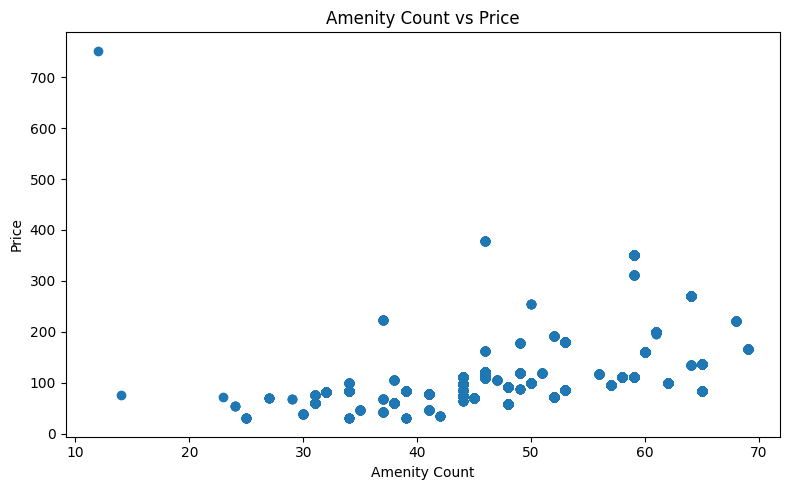

In [182]:
plt.figure(figsize=(8, 5))
plt.scatter(dfc["amenity_count"], dfc["price"])
plt.title("Amenity Count vs Price")
plt.xlabel("Amenity Count")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

#### Amenities and review scores

Checking whether listings with certain amenities tend to receive different review scores.

In [183]:
for col in important_amenities:
    print(f"\nAverage review score by {col}:")
    print(dfc.groupby(col)["review_scores_rating"].mean())


Average review score by has_wifi:
has_wifi
0    4.662157
1    4.920847
Name: review_scores_rating, dtype: float64

Average review score by has_kitchen:
has_kitchen
0    4.934434
1    4.915624
Name: review_scores_rating, dtype: float64

Average review score by has_air_conditioning:
has_air_conditioning
0    4.829167
1    4.919798
Name: review_scores_rating, dtype: float64

Average review score by has_parking:
has_parking
0    4.993333
1    4.919627
Name: review_scores_rating, dtype: float64

Average review score by has_pool:
has_pool
0    4.919032
1    4.927958
Name: review_scores_rating, dtype: float64

Average review score by has_hot_tub:
has_hot_tub
0    4.919470
1    4.935205
Name: review_scores_rating, dtype: float64

Average review score by has_workspace:
has_workspace
0    4.922696
1    4.915718
Name: review_scores_rating, dtype: float64

Average review score by has_pet_friendly:
has_pet_friendly
0    4.910663
1    4.932716
Name: review_scores_rating, dtype: float64

Average rev

The results show that amenities have a much smaller effect on review scores compared to price. Most average review scores are very high (close to 5), and the differences between listings with and without certain amenities are relatively small.

Some amenities show slight positive differences, such as WiFi, air conditioning, and hot tubs, but the changes are minimal. In many cases, the averages are nearly identical regardless of whether the amenity is present.

This suggests that amenities may not strongly influence review scores because many basic features are already expected by guests. Instead, reviews are likely influenced more by factors such as cleanliness, communication, and overall experience rather than individual amenities.

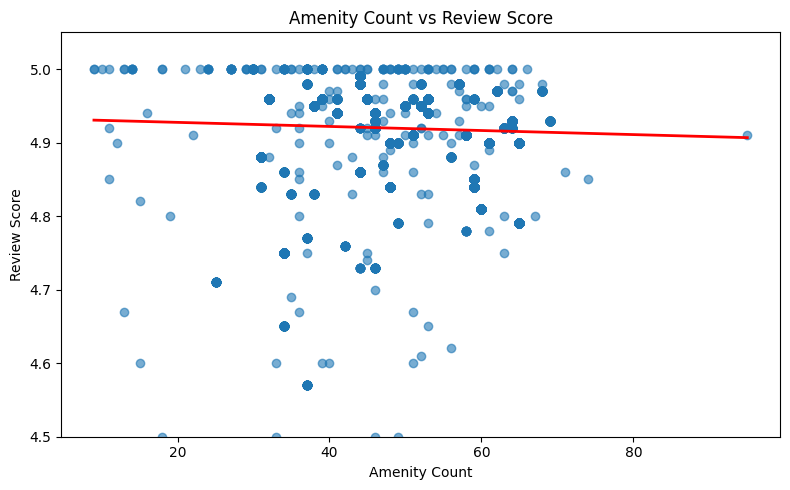

Slope: -0.00027688913642771504


In [184]:
plt.figure(figsize=(8, 5))

# clean data first (IMPORTANT)
temp = dfc[["amenity_count", "review_scores_rating"]].dropna()

x = temp["amenity_count"].values
y = temp["review_scores_rating"].values

# scatter
plt.scatter(x, y, alpha=0.6)

# fit line
z = np.polyfit(x, y, 1)

# create a SIMPLE straight line (guaranteed visible)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = z[0] * x_line + z[1]

# plot ON TOP, very bold
plt.plot(x_line, y_line, color="red", linewidth=2, zorder=100)

plt.title("Amenity Count vs Review Score")
plt.xlabel("Amenity Count")
plt.ylabel("Review Score")

plt.ylim(4.5, 5.05)

plt.tight_layout()
plt.show()

print("Slope:", z[0])

The scatter plot of amenity count versus review score shows that most listings receive high ratings regardless of how many amenities they offer. While there is a slight upward trend, the relationship is weak, and review scores remain clustered near the top of the scale.

This reinforces the idea that having more amenities does not necessarily lead to significantly higher ratings. Guests appear to rate listings highly as long as basic expectations are met.

### Linear Regression Model

How well they explain price and review scores.

#### Model 1: Predict PRICE

In [185]:
# select features
features = [
    "amenity_count",
    "has_wifi",
    "has_kitchen",
    "has_air_conditioning",
    "has_parking",
    "has_pool",
    "has_hot_tub",
    "has_workspace",
    "has_pet_friendly",
    "has_view"
]

# clean dataset
model_dfc = dfc[features + ["price"]].dropna()

X = model_dfc[features]
y = model_dfc["price"]

# create model
model = LinearRegression()
model.fit(X, y)

# predictions
y_pred = model.predict(X)

# coefficients
coef_dfc = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coef_dfc)
print("\nIntercept:", model.intercept_)

                Feature  Coefficient
0         amenity_count     2.264675
1              has_wifi   -13.277075
2           has_kitchen    10.269327
3  has_air_conditioning   -31.796157
4           has_parking   139.393401
5              has_pool   -40.135184
6           has_hot_tub    91.699312
7         has_workspace    14.368196
8      has_pet_friendly    -6.164667
9              has_view    32.666359

Intercept: -118.26254202773245


The regression coefficients show how each feature affects price while holding all other variables constant.

The amenity_count variable has a positive coefficient (~2.26), meaning that each additional amenity is associated with about a $2 increase in price. This suggests that having more amenities overall slightly increases listing value.

Some individual amenities have strong positive effects. Parking (~+139), hot tubs (~+92), and views (~+33) are associated with higher prices, indicating that these features are likely considered premium by guests.

Other amenities have negative coefficients, such as air conditioning (~-32), pools (~-40), and WiFi (~-13). These results likely reflect that these amenities are common or expected, so they do not increase price and may appear negative when controlling for other features.

Overall, the model suggests that higher-end or less common amenities (like hot tubs and views) contribute more to price, while basic amenities do not significantly increase value.

In [186]:
from sklearn.metrics import r2_score

print("R²:", r2_score(y, y_pred))

R²: 0.42677458712491334


The R² value of approximately 0.43 indicates that the model explains about 43% of the variation in listing prices. This suggests that amenities play a meaningful role in determining price, but they are not the only factor.

Other variables such as location, property size, and listing characteristics likely account for the remaining variation in price.

### Bar chart of feature importance

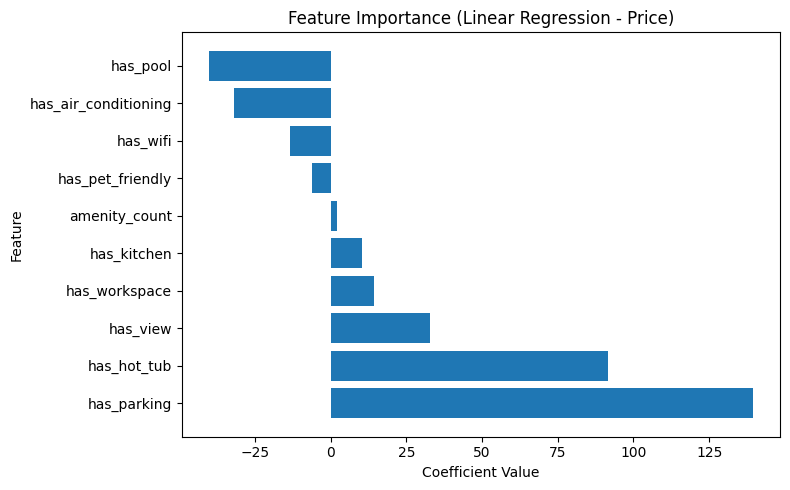

In [187]:
coef_dfc_sorted = coef_dfc.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(coef_dfc_sorted["Feature"], coef_dfc_sorted["Coefficient"])
plt.title("Feature Importance (Linear Regression - Price)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance chart highlights which amenities have the strongest impact on price based on the regression model.

Parking has the largest effect by a wide margin, followed by hot tubs and views. These amenities appear to significantly increase listing prices and are likely considered premium features.

Workspaces and kitchens have smaller positive effects, suggesting they add value but are less influential.

Amenities such as WiFi, air conditioning, and pools have negative coefficients. This does not mean they reduce price, but rather that they are common features that do not differentiate higher-priced listings when other variables are considered.

Amenity count has a small positive effect, indicating that having more amenities overall contributes to higher prices, but not as strongly as specific high-value features.

Overall, the chart reinforces that luxury or less common amenities drive price more than basic ones.

### Decision tree

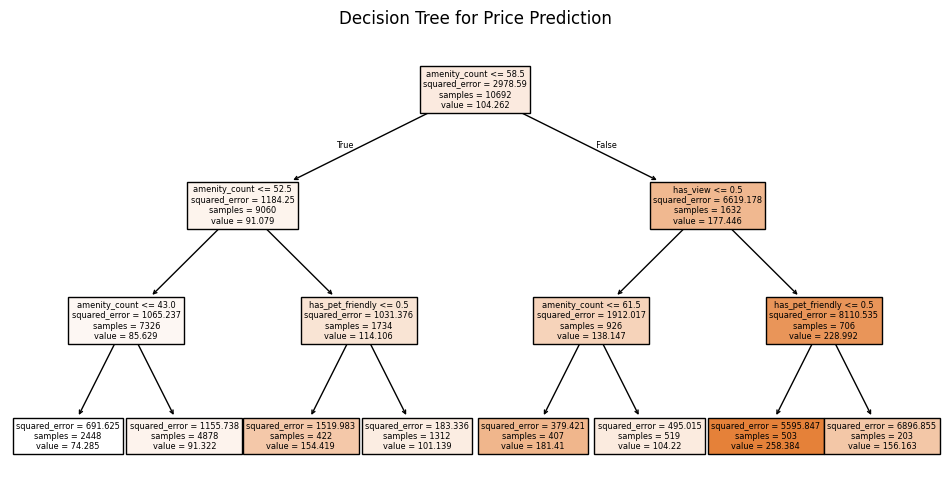

In [188]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X, y)

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=features, filled=True)
plt.title("Decision Tree for Price Prediction")
plt.show()

The decision tree provides a more interpretable, rule-based view of how amenities influence price.

The first split is based on amenity count, indicating that the total number of amenities is the most important factor in determining price.

Listings with higher amenity counts tend to have higher predicted prices, while those with fewer amenities are grouped into lower price ranges.

Further splits show that specific amenities, such as having a view or being pet-friendly, help refine price predictions within those groups. For example, listings with a view and many amenities tend to fall into higher price categories.

The tree structure also shows that combinations of features matter. Instead of looking at one amenity at a time, the model identifies how multiple factors interact to influence price.

Overall, the decision tree supports the earlier findings that both the number of amenities and certain high-value features play an important role in pricing, while simpler amenities have less impact.

#### Comparing model performance

In [189]:
from sklearn.metrics import r2_score

tree_pred = tree.predict(X)

print("Linear R²:", r2_score(y, y_pred))
print("Tree R²:", r2_score(y, tree_pred))

Linear R²: 0.42677458712491334
Tree R²: 0.596859002800884


The linear regression model achieved an R² of approximately 0.43, meaning it explains about 43% of the variation in price.

The decision tree model achieved a higher R² of approximately 0.60, indicating it explains about 60% of the variation in price.

This suggests that the decision tree provides a better fit to the data than the linear regression model. One reason for this is that decision trees can capture non-linear relationships and interactions between features, while linear regression assumes a simple linear relationship.

Overall, the results indicate that price is influenced by more complex relationships between amenities, and the decision tree is better able to model those patterns.

### Amenities Final Takeaway

Amenities do influence Airbnb prices, especially higher-end features like hot tubs, parking, and views. However, they do not strongly affect review scores. This suggests that while amenities help determine how much a listing costs, guest ratings depend more on overall experience rather than specific features.

## Natural Language Processing (NLP) Section

In [190]:
#Initialize VADER
sia = SentimentIntensityAnalyzer()

#Drop null comments since they won't contain needed information
reviews_clean = reviews.dropna(subset=['comments']).copy()

#Run VADER on every review and compound score ranges from -1 (most negative) to +1 (most positive)
reviews_clean['sentiment_score'] = reviews_clean['comments'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

#The mean sentiment is helpful to see if we have a good range of data (we already know it will be left-skewed)
print(f"\nMean sentiment: {reviews_clean['sentiment_score'].mean():.3f}")
print(f"Min: {reviews_clean['sentiment_score'].min():.3f} | Max: {reviews_clean['sentiment_score'].max():.3f}")


Mean sentiment: 0.826
Min: -0.981 | Max: 0.999


We can see from the output that even though the data is heavily left-skewed and the mean sentiment is 0.826, there's still meaningful variation in the sentiment range of min and max. Now, we need to aggregate the sentiment scores to listing level so that we can mutate it into the listings.detail csv. There are 61 listings with no sentiment scores since they include no reviews. Out of those 61, 27 of them do have ratings. We chose to impute the missing sentiment scores with the median by room type, similar to what we did with price. We now have the features to use in our regression model.

In [191]:
#Aggregate sentiment scores to listing level
sentiment_by_listing = reviews_clean.groupby('listing_id').agg(
    mean_sentiment=('sentiment_score', 'mean'),
    min_sentiment=('sentiment_score', 'min'),
    review_count=('sentiment_score', 'count')
).reset_index()

#Merge into listings_detail

listings_detail = listings_detail.merge(
    sentiment_by_listing,
    left_on='id',
    right_on='listing_id',
    how='left'
).drop(columns='listing_id')


print(f"\nNulls in mean_sentiment: {listings_detail['mean_sentiment'].isnull().sum()}")


#Check if listings with no sentiment have ratings, and see if we should impute the sentiment score
no_reviews = listings_detail[listings_detail['mean_sentiment'].isnull()]
print(f"Listings with no reviews: {len(no_reviews)}")
print(f"Of those, how many have a rating: {no_reviews['review_scores_rating'].notna().sum()}")


Nulls in mean_sentiment: 61
Listings with no reviews: 61
Of those, how many have a rating: 27


In [192]:
#Impute missing sentiment with median by room type
listings_detail['mean_sentiment'] = listings_detail.groupby('room_type')['mean_sentiment'].transform(
    lambda x: x.fillna(x.median())
)

listings_detail['min_sentiment'] = listings_detail.groupby('room_type')['min_sentiment'].transform(
    lambda x: x.fillna(x.median())
)

#For review count, fill with 0 since they genuinely have no reviews
listings_detail['review_count'] = listings_detail['review_count'].fillna(0)

#check that there are no more nulls in the data
print(f"Nulls in mean_sentiment: {listings_detail['mean_sentiment'].isnull().sum()}")
print(f"Nulls in min_sentiment: {listings_detail['min_sentiment'].isnull().sum()}")
print(f"Nulls in review_count: {listings_detail['review_count'].isnull().sum()}")

Nulls in mean_sentiment: 0
Nulls in min_sentiment: 0
Nulls in review_count: 0


In [193]:
airbnb_model = listings_detail[["mean_sentiment", "review_scores_rating"]].dropna()

X = airbnb_model[["mean_sentiment"]]
y = airbnb_model["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# define and fit model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R^2:", r2)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

MSE: 0.03758838265260266
R^2: 0.18620488314095018
Intercept: 4.044361388828617
Coefficient: 1.0060378575945386


The R^2 of 0.08 conveys that guest review tone alone isn't enough to predict a listing's rating. The intercept of 4.02 means that a listing with a neutral sentiment score (0) would be predicted to have a rating of ~4.02, which is reasonable.

The next section splits the listings by rating, with high-rating as 4.9+ and the others as low-rating, since the ratings are so heavily left-skewed with a mean of 4.86 (from EDA). On the first try, we chose to extract the top 20 keywords for each group.

In [194]:
#TF-IDF section
#Split listings into high and low rated (4.9+ is high_rated and lower is low_rated, because of mean being so high)
high_rated = listings_detail[listings_detail['review_scores_rating'] >= 4.9]['id'].tolist()
low_rated = listings_detail[listings_detail['review_scores_rating'] < 4.9]['id'].tolist()

#Get all reviews for each group
high_reviews = reviews_clean[reviews_clean['listing_id'].isin(high_rated)]['comments'].str.cat(sep=' ')
low_reviews = reviews_clean[reviews_clean['listing_id'].isin(low_rated)]['comments'].str.cat(sep=' ')

#Run TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform([high_reviews, low_reviews])

#Extract top 20 keywords for each group
feature_names = tfidf.get_feature_names_out()
high_scores = tfidf_matrix[0].toarray()[0]
low_scores = tfidf_matrix[1].toarray()[0]

top_high = sorted(zip(feature_names, high_scores), key=lambda x: x[1], reverse=True)[:20]
top_low = sorted(zip(feature_names, low_scores), key=lambda x: x[1], reverse=True)[:20]

print("Top keywords for HIGH rated listings:")
print([word for word, score in top_high])

print("\nTop keywords for LOW rated listings:")
print([word for word, score in top_low])

Top keywords for HIGH rated listings:
['stay', 'place', 'great', 'clean', 'comfortable', 'home', 'salem', 'nice', 'host', 'br', 'house', 'beautiful', 'space', 'definitely', 'perfect', 'quiet', 'recommend', 'elizabeth', 'location', 'room']

Top keywords for LOW rated listings:
['stay', 'place', 'great', 'clean', 'home', 'comfortable', 'nice', 'house', 'host', 'br', 'salem', 'location', 'quiet', 'definitely', 'perfect', 'space', 'recommend', 'needed', 'beautiful', 'easy']


As you can see, there isn't much variability  or difference in the top keywords for high vs low rated listings. Next, we decided to look at which words are proportionally more common.

In [195]:
#Compare which words are proportionally MORE common in high vs low
word_diff = {}
for word, h_score, l_score in zip(feature_names, high_scores, low_scores):
    if h_score + l_score > 0:  # avoid division by zero
        word_diff[word] = h_score - l_score  # positive = more common in high rated

#Top words MORE common in high rated
top_high_unique = sorted(word_diff.items(), key=lambda x: x[1], reverse=True)[:20]
#Top words MORE common in low rated
top_low_unique = sorted(word_diff.items(), key=lambda x: x[1])[:20]

print("Words MORE associated with HIGH rated listings:")
print([word for word, score in top_high_unique])

print("\nWords MORE associated with LOW rated listings:")
print([word for word, score in top_low_unique])

Words MORE associated with HIGH rated listings:
['elizabeth', 'leigh', 'beautiful', 'julie', 'bob', 'delia', 'sara', 'bob delia', 'salem', 'mary', 'lou', 'mary lou', 'highly', 'room', 'space', 'comfortable', 'wonderful', 'shana', 'highly recommend', 'snacks']

Words MORE associated with LOW rated listings:
['maria', 'nice', 'emily', 'ian', 'house', 'kathie', 'good', 'matthew', 'emily ian', 'creek', 'amanda', 'great', 'family', 'judy', 'jolie', 'location', 'kitchen', 'beds', 'overall', 'hosts']


We're seeing a bit more variability here, but a lot of host names are appearing. To have a word cloud that describes the property and not the host, we extracted host names and also words that were common filler words in the airbnb csv. 

In [196]:
#Extract host names from listings and clean them
host_names = listings_detail['host_name'].dropna().str.lower().str.split().explode().unique().tolist()

#Combine with standard english stop words + common airbnb filler words
custom_stop_words = list(stopwords.words('english')) + host_names + [
    'br', 'stay', 'stayed', 'airbnb', 'salem', 'place', 'great', 
    'good', 'nice', 'just', 'really', 'very', 'also', 'would', 
    'get', 'got', 'like', 'one', 'us', 'wa', 'need','ian','bill'
]

#Rerun TF-IDF with custom stop words
tfidf = TfidfVectorizer(max_features=1000, stop_words=custom_stop_words, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform([high_reviews, low_reviews])

feature_names = tfidf.get_feature_names_out()
high_scores = tfidf_matrix[0].toarray()[0]
low_scores = tfidf_matrix[1].toarray()[0]

word_diff = {}
for word, h_score, l_score in zip(feature_names, high_scores, low_scores):
    if h_score + l_score > 0:
        word_diff[word] = h_score - l_score

top_high_unique = sorted(word_diff.items(), key=lambda x: x[1], reverse=True)[:20]
top_low_unique = sorted(word_diff.items(), key=lambda x: x[1])[:20]

print("Words MORE associated with HIGH rated listings:")
print([word for word, score in top_high_unique])
print("\nWords MORE associated with LOW rated listings:")
print([word for word, score in top_low_unique])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['areli'] not in stop_words.
  warnings.warn(


Words MORE associated with HIGH rated listings:
['beautiful', 'highly', 'room', 'space', 'wonderful', 'snacks', 'highly recommend', 'comfortable', 'loft', 'touches', 'bed', 'loved', 'recommend', 'amenities', 'fresh', 'neighborhood', 'lovely', 'garage', 'absolutely', 'time']

Words MORE associated with LOW rated listings:
['house', 'creek', 'family', 'location', 'kitchen', 'beds', 'hosts', 'overall', 'friendly', 'unit', 'responsive', 'cat', 'small', 'cottage', 'backyard', 'bedroom', 'back', 'home', 'bathroom', 'people']


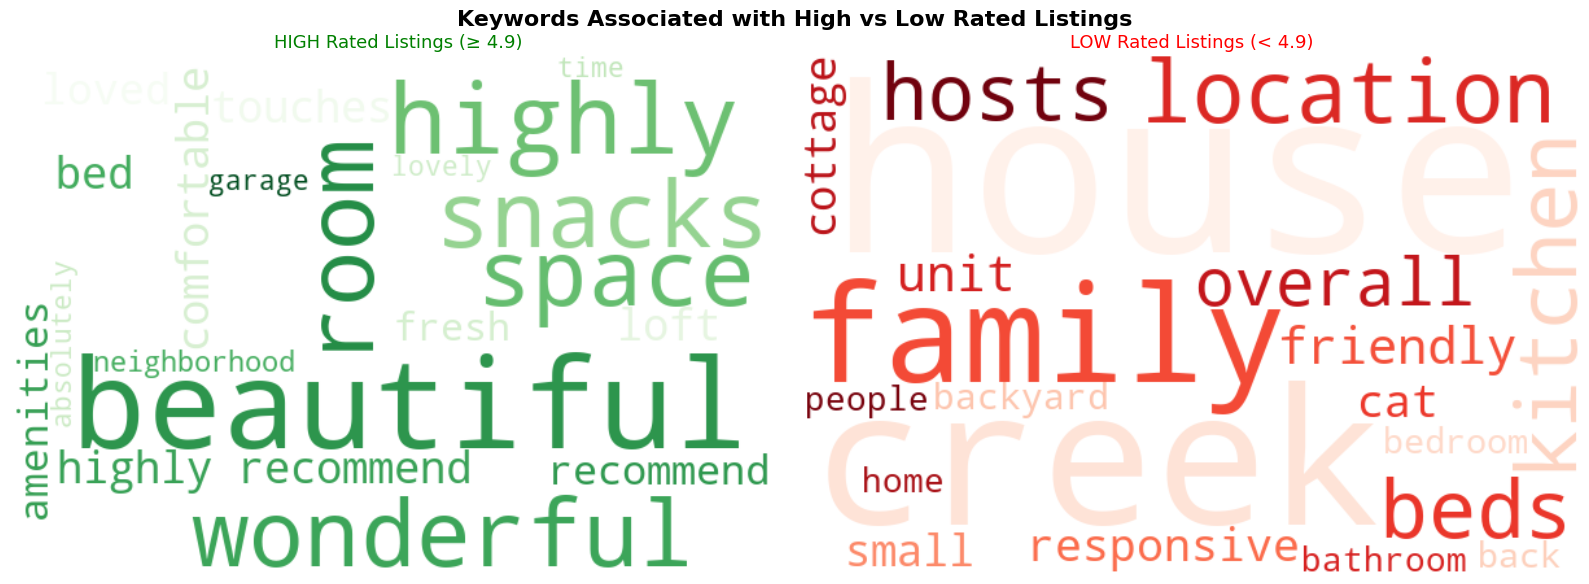

In [197]:
# The layout changes every time so this will look different from the presentation slides.


#Creating the word cloud for visualization
high_dict = {word: score for word, score in top_high_unique if score > 0}
low_dict = {word: abs(score) for word, score in top_low_unique if score < 0}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Keywords Associated with High vs Low Rated Listings', fontsize=16, fontweight='bold')

#High rated word cloud
wc_high = WordCloud(
    width=600, height=400, 
    background_color='white',
    colormap='Greens'
).generate_from_frequencies(high_dict)
axes[0].imshow(wc_high, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('HIGH Rated Listings (≥ 4.9)', fontsize=13, color='green')

# Low rated word cloud
wc_low = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Reds'
).generate_from_frequencies(low_dict)
axes[1].imshow(wc_low, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('LOW Rated Listings (< 4.9)', fontsize=13, color='red')

plt.tight_layout()
plt.show()

We finally see some interesting trends in the data. There seems to be a focus on phsyical space for both ratings, with the high ratings highlighting "space", "room","loft", while low ratings showed repeats of "small", "bathroom", "bedroom", "backyard", and "kitchen". Guests who rated the properties lower may be have been disappointed with the accuracy of the property based off the pictures on the app. 
In the high-rated listings, there are words like touches, snacks, garage, fresh, that imply that personal touches and unique amenities that enhance the guest's experiences may lead to higher ratings.
In the low-rated listings, location seems to be a large factor into the reviews. This could also be an accuracy issue of the property listing, with guests unhappy that they aren't as close to geo marks as it may have seemed in the listing.

## Conclusion
### For Hosts
Salem's Airbnb market has grown nearly fivefold since 2018, and with more listings entering the market every year, differentiation becomes essential. Our analysis offers a clear roadmap for hosts looking to maximize both their rating and their pricing power.The biggest price increases came from high-impact amenities like parking, hot tubs, and views, while properties with historical architectural features consistently met with higher prices. Importantly, simply offering more amenities correlates with higher pricing, but they are not all valued equally. Guests expect basics like WiFi and AC, and these won't justify higher prices or earn better reviews. What separates top-rated listings are the personal touches, for example, something as simple as leaving snacks for guests was among the strongest predictors of high ratings in our keyword analysis. Hosts should also prioritize accuracy in their listings and remain responsive to guests throughout the entire stay, not just at the booking stage. In a market where nearly every listing scores above 4.5 stars, the difference between a good listing and a great one comes down to the details.

### For Customers
Our biggest recommmendation is to check the accuracy reviews, since matching the expectations of the customer booking the property is essential. Our findings show that higher prices reflect the features a listing offers more than the quality of the experience itself, so guests should resist the assumption that paying more guarantees a better stay.
Instead, focus on the amenities that actually matter to you. Reading recent reviews remains one of the most valuable tools available, which our sentiment analysis confirmed that the language guests use tells a richer story than the star rating alone. Pay attention to what reviewers say about cleanliness, communication, and accuracy, as these sub-scores were among the strongest predictors of overall satisfaction.

Finally, if you're planning a summer trip to Salem, book early, since July is peak season and availability tightens significantly, with demand patterns suggesting that summer travelers who wait risk paying more or missing out entirely.

## Future Work and Explorations
These datasets offered a rich set of features to explore. With time limitations for this project, we chose the ones that aligned best with our research questions. However, with more time, we would like to look at other features like bedrooms, bathrooms, availability in coming months, min and max stay requirements, and number of reviews. Additionaly, a geospatial analysis on how distance to key landmarks affects pricing would be complimentary model to add.

We'd also like to move beyond prediction and are interested in a tool that could put these model's insights into recommendations. Hosts would be able to input their amenities and features, and the model would return personalized suggestions on what to prioritize to improve their listing or advertise more effectively. Customers would be able to input thier priorities for what they want in an Airbnb and the model could suggest some properties that best meet their needs.